# Causal Discovery and Causal Feature Selection for Robust Prediction

This tutorial walks through the key ideas and algorithms at the intersection of causal inference and machine learning. The central thread is this: **can we do better than standard feature selection when we care about robustness under distribution shift?**

We will work through the problem from the ground up — starting with pairwise causal direction tests, moving to full multivariate graph recovery, then to causal feature selection (CFS), and finally comparing CFS-based predictors with standard ones under intervention shifts.

The tutorial is structured as follows:

1. **Pairwise causal discovery** — can we tell which variable causes which, from observational data alone?
2. **Multivariate causal discovery** — recovering the full causal graph over many variables
3. **Multivariate causal feature selection** — finding the Markov Blanket of a target variable
4. **CFS for robust prediction** — why causal parents are more stable predictors than correlated features
5. **Invariant Causal Predictors** — a principled method to find invariant features across environments

---
**Prerequisites:** basic probability, linear regression, familiarity with Python/sklearn.  
**Packages used:** `numpy`, `sklearn`, `causallearn`, `cdt`, `dcor`, and custom helpers (`generate_scm`, `MB`, `causal_discovery`, `causal_feature_selection`).


In [1]:
# Standard library
import time

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# SciPy / stats
from scipy.stats import pearsonr
from numpy.linalg import lstsq

# Scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Other statistical tools
import dcor

# Causal inference / discovery
from causallearn.utils.KCI.KCI import KCI_UInd
from causal_discovery import ges, adjacency, pc_alg, fci_alg, lingam
from causal_feature_selection import (
    hiton_mb, iamb, mmpc, mb_ges, resit_mb, hiton_pc
)
from invariant_causal_prediction import icp
from kci import kci_test

# Data utilities
from cdt.data import load_dataset

# Custom modules
from generate_scm import *
from MB import *

# Reproducibility
np.random.seed(2)

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


---
## Section 1.5 — Markov Equivalence Classes

### The fundamental identifiability barrier

After seeing pairwise RESIT, it is tempting to hope that a multivariate generalisation can always recover a fully directed graph from observational data alone. Unfortunately, **this is impossible in general** — and understanding why is essential before using any constraint-based algorithm like PC, FCI, or their variants.

### 1.5.1 A minimal example: three variables

Consider three variables X0, X1, X2 and the following three DAGs:

```
(1)  X0 → X1 → X2        (chain)
(2)  X0 ← X1 → X2        (fork / common cause)
(3)  X0 → X1 ← X2        (collider / v-structure)
```

In DAGs (1) and (2), X0 and X2 are **marginally dependent** but **conditionally independent given X1** — written X0 ⊥ X2 | X1. In DAG (3), X0 and X2 are **marginally independent** but become **dependent when conditioning on X1** (the collider — a classic Berkson’s paradox).

This distinction is testable from data. But crucially, **(1) and (2) are indistinguishable from observational data alone**: they encode exactly the same conditional independencies. No statistical test — however large the sample — can tell them apart.

### 1.5.2 Markov Equivalence Classes (MEC)

Two DAGs are **Markov equivalent** if and only if they have the same skeleton (undirected edges) and the same **v-structures** (patterns X → Z ← Y where X and Y are not adjacent). This is the Verma–Pearl theorem.

The set of all Markov-equivalent DAGs forms the **Markov Equivalence Class (MEC)**. Constraint-based algorithms can recover only the MEC. Their output is a **CPDAG** (Completed Partially Directed Acyclic Graph): edges that point the same way across all DAGs in the MEC appear as arrows; edges that could go either way appear as undirected lines.

### 1.5.3 What PC orients and what it leaves undirected

PC proceeds in two phases:

1. **Skeleton recovery**: remove edges wherever a conditional independence is found.
2. **Orientation**: orient v-structures (forced by the data), then propagate via Meek rules without creating new v-structures or cycles.

Edges that cannot be oriented by these rules remain undirected. On a simple chain with no v-structures, *no* edge can be oriented — PC returns a fully undirected skeleton.

### 1.5.4 Setup

We use the same `SCMGenerator` infrastructure as the rest of the tutorial to build each of the three 3-variable DAGs and sample data from them.

True DAGs:


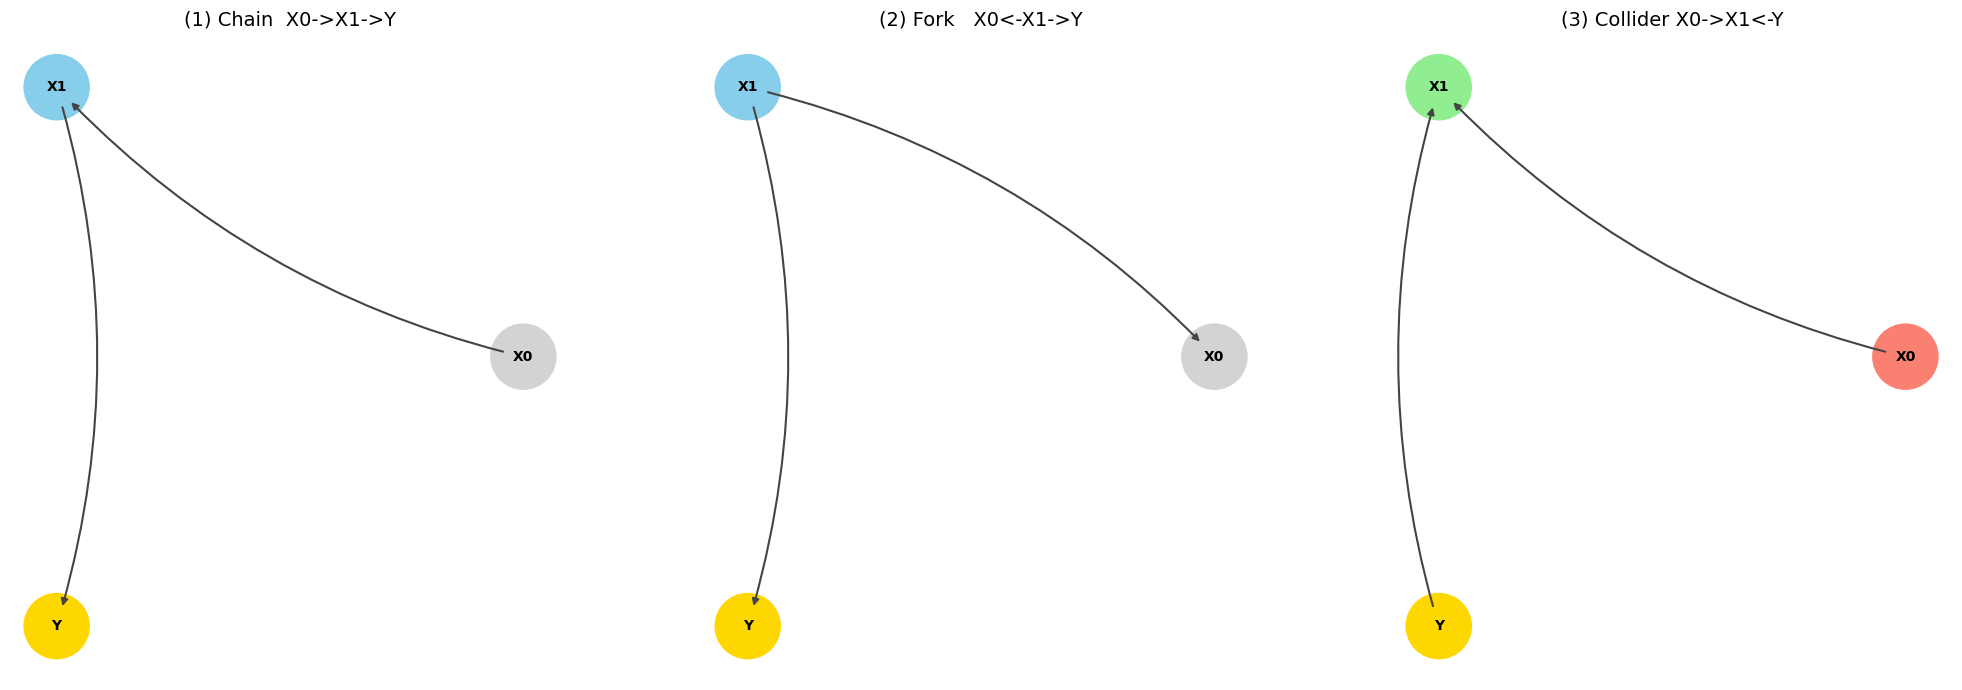

In [5]:

# ----------------------------------------------------------------
# Build three 3-variable SCMs manually via adjacency matrices
# Variables: X0, X1, X2  (d=2, so Y is X2 in the SCM framework)
# ----------------------------------------------------------------
d = 2  # 2 non-target vars + target Y => 3 nodes total

def make_scm_from_adj(A_matrix, seed=13):
    np.random.seed(seed)
    scm = SCMGenerator(d=d)
    scm.fit_from_adjacency(A_matrix, Y_idx=d,
                           noise_type='uniform', is_linear=True)
    return scm

col_names = ['X0', 'X1', 'Y']  # Y plays the role of X2

# (1) Chain:    X0 -> X1 -> Y
A_chain = np.array([[0, 1, 0],
                    [0, 0, 1],
                    [0, 0, 0]], dtype=float)

# (2) Fork:     X0 <- X1 -> Y   (X1 is the common cause)
A_fork  = np.array([[0, 0, 0],
                    [1, 0, 1],
                    [0, 0, 0]], dtype=float)

# (3) Collider: X0 -> X1 <- Y
A_coll  = np.array([[0, 1, 0],
                    [0, 0, 0],
                    [0, 1, 0]], dtype=float)

scm_chain = make_scm_from_adj(A_chain)
scm_fork  = make_scm_from_adj(A_fork)
scm_coll  = make_scm_from_adj(A_coll)

print('True DAGs:')
plot_graphs_from_adj([A_chain, A_fork, A_coll],
                     Y_idx_list=[d, d, d],
                     plot_titles=['(1) Chain  X0->X1->Y',
                                  '(2) Fork   X0<-X1->Y',
                                  '(3) Collider X0->X1<-Y'])


### 1.5.5 Sample data and check independence structure

We sample 5000 observations from each SCM and verify the key claim:
the chain and the fork produce **identical** conditional independence patterns,
while the collider differs.

In [6]:

n_samples = 2000
data_chain = scm_chain.sample(n_samples=n_samples)
data_fork  = scm_fork.sample(n_samples=n_samples)
data_coll  = scm_coll.sample(n_samples=n_samples)

def partial_corr(df, x, y, z):
    """Partial correlation of x and y after regressing out z."""
    bx = lstsq(df[[z]].values, df[x].values, rcond=None)[0][0]
    by = lstsq(df[[z]].values, df[y].values, rcond=None)[0][0]
    res_x = df[x].values - bx * df[z].values
    res_y = df[y].values - by * df[z].values
    r, p = pearsonr(res_x, res_y)
    return r, p

print(f'{"SCM":<22}  {"X0-Y marginal":>20}  {"X0-Y | X1 (partial)":>22}')
print('-' * 68)
for name, df in [('Chain  (X0->X1->Y)', data_chain),
                  ('Fork   (X0<-X1->Y)', data_fork),
                  ('Collider (X0->X1<-Y)', data_coll)]:
    r_m, p_m = pearsonr(df['X0'], df['Y'])
    r_c, p_c = partial_corr(df, 'X0', 'Y', 'X1')
    sig_m = '***' if p_m < 0.001 else ('*' if p_m < 0.05 else 'n.s.')
    sig_c = '***' if p_c < 0.001 else ('*' if p_c < 0.05 else 'n.s.')
    print(f'{name:<22}  r={r_m:+.3f} ({sig_m:>3})          r={r_c:+.3f} ({sig_c:>3})')

print()
print('Chain and Fork: same marginal dependence, same conditional independence.')
print('Collider:       marginal independence, but conditional dependence.')


SCM                            X0-Y marginal     X0-Y | X1 (partial)
--------------------------------------------------------------------
Chain  (X0->X1->Y)      r=+0.882 (***)          r=+0.008 (n.s.)
Fork   (X0<-X1->Y)      r=-0.881 (***)          r=-0.006 (n.s.)
Collider (X0->X1<-Y)    r=-0.011 (n.s.)          r=+0.871 (***)

Chain and Fork: same marginal dependence, same conditional independence.
Collider:       marginal independence, but conditional dependence.


### 1.5.6 Running PC, GES and FCI on each dataset

Now we actually run the three discovery algorithms on each dataset and display the recovered CPDAGs side by side.
The key prediction:
- Chain and Fork should produce **identical** CPDAGs (undirected path X0 — X1 — Y).
- Collider should yield the **oriented v-structure** X0 → X1 ← Y.

Running causal discovery algorithms...
Chain     |  PC: 0.01s  GES: 0.16s
Fork      |  PC: 0.00s  GES: 0.15s
Collider  |  PC: 0.02s  GES: 0.15s

=== Chain: recovered CPDAGs ===


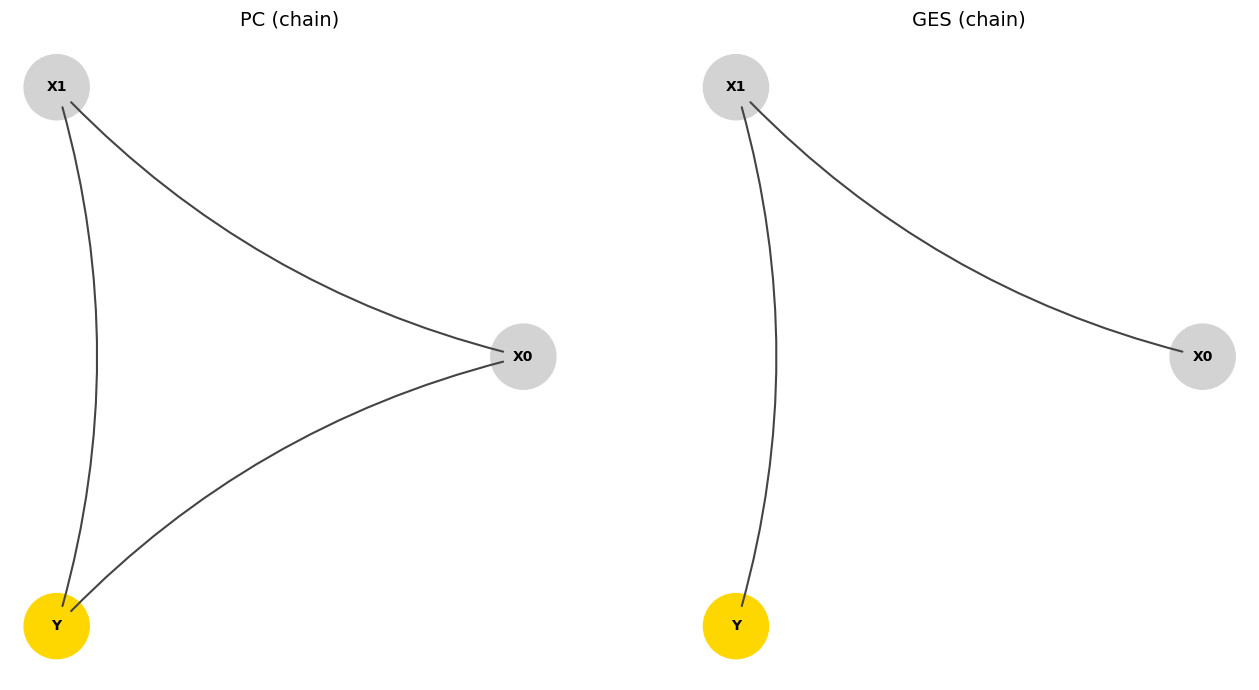

=== Fork: recovered CPDAGs (should match chain!) ===


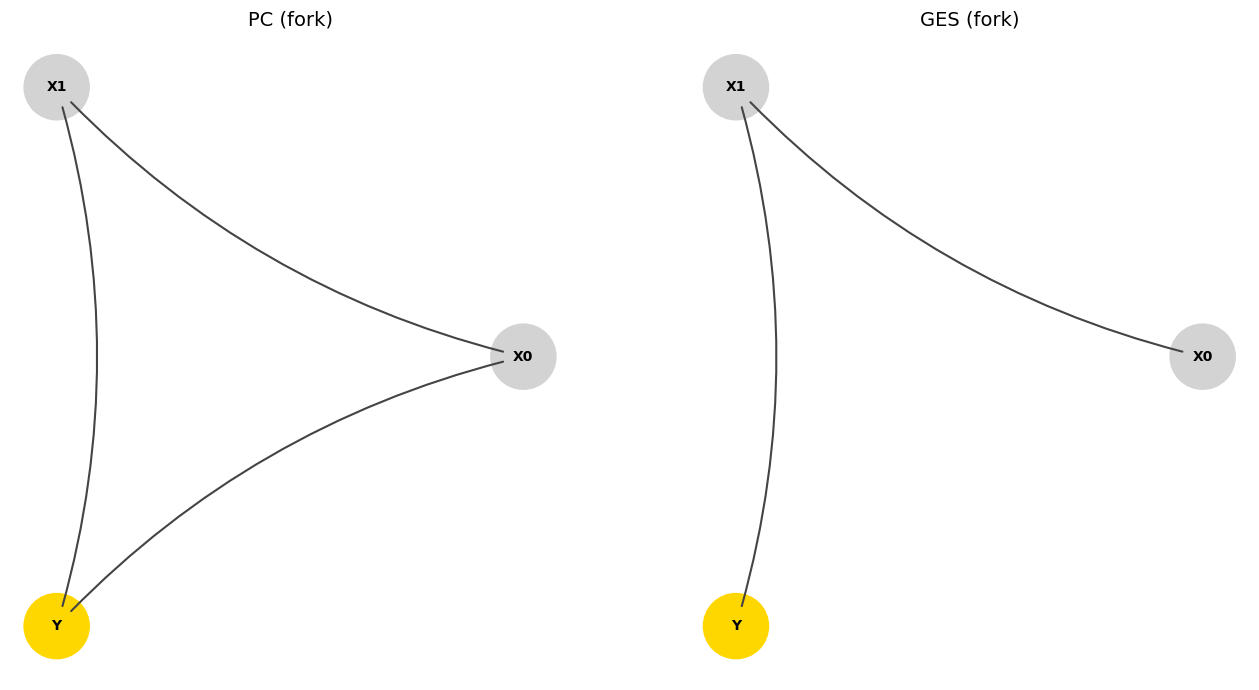

=== Collider: recovered CPDAGs (v-structure should be oriented) ===


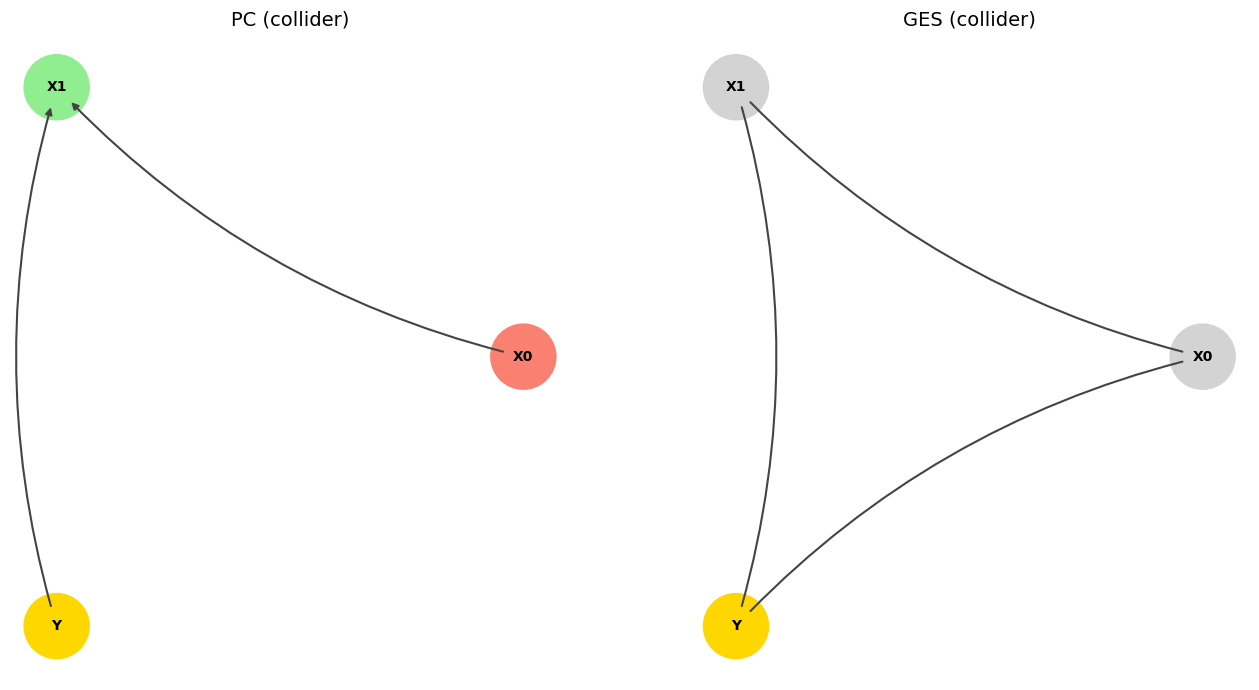

In [7]:
def run_all(data, label):
    t0 = time.time(); A_pc  = adjacency(pc_alg(data));  t_pc  = time.time()-t0
    t0 = time.time(); A_ges = adjacency(ges(data));     t_ges = time.time()-t0
    print(f'{label}  |  PC: {t_pc:.2f}s  GES: {t_ges:.2f}s')
    return A_pc, A_ges

print('Running causal discovery algorithms...')
pc_ch, ges_ch = run_all(data_chain, 'Chain   ')
pc_fo, ges_fo = run_all(data_fork,  'Fork    ')
pc_co, ges_co = run_all(data_coll,  'Collider')

print()
print('=== Chain: recovered CPDAGs ===')
plot_graphs_from_adj([pc_ch.values, ges_ch.values],
                     Y_idx_list=[d, d, d],
                     plot_titles=['PC (chain)', 'GES (chain)'])

print('=== Fork: recovered CPDAGs (should match chain!) ===')
plot_graphs_from_adj([pc_fo.values, ges_fo.values],
                     Y_idx_list=[d, d, d],
                     plot_titles=['PC (fork)', 'GES (fork)'])

print('=== Collider: recovered CPDAGs (v-structure should be oriented) ===')
plot_graphs_from_adj([pc_co.values, ges_co.values],
                     Y_idx_list=[d, d, d],
                     plot_titles=['PC (collider)', 'GES (collider)'])


In [8]:
a, b = pc_alg(data, return_ci=True)

In [9]:
adjacency(a)

,Y,res_yx
Y,0,0
res_yx,0,0


### 1.5.7 Beyond equivalence classes

All three algorithms produce the same undirected skeleton for the chain and the fork — **no algorithm based solely on conditional independence tests can resolve this ambiguity**, regardless of sample size.

To orient the remaining undirected edges, additional information is needed:

| Additional assumption | Method | What it recovers |
|---|---|---|
| Non-Gaussian noise | LiNGAM | Full DAG |
| Nonlinear mechanisms | ANM / RESIT | Full DAG |
| Interventional data | IDA, GIES | Partially or fully oriented |
| Temporal ordering | DYNOTEARS | Full DAG (time series) |
| Background knowledge | PC + constraints | Partially oriented |

This is exactly the regime where pairwise RESIT (Section 1) has power: non-Gaussian or nonlinear noise lets us go beyond the MEC. In Section 5, we will see how **ICP uses multiple environments** (interventions) to achieve the same goal indirectly.

### Questions — Equivalence classes

**Q_EC1.** Look at the chain output above. The edge X0—X1 and X1—Y are both undirected. List all distinct DAGs over three nodes that share this skeleton and have no v-structures. How many are in the MEC?

**Q_EC2.** A researcher argues: "I have 100,000 samples, so my independence tests are very powerful — I should be able to orient all edges." Why is this argument fundamentally wrong?

**Q_EC3.** Change `noise_type='uniform'` to `noise_type='gaussian'` in the SCM generation above and re-run. Do the results change? Now imagine you switched to a LiNGAM algorithm — would it help with Gaussian noise? Why or why not?

---

**Answers:**

**A_EC1.** On a 3-node path, there are three orientation patterns with no v-structure: X0→X1→Y, X0←X1←Y, X0←X1→Y (the fork). The fourth orientation X0→X1←Y *is* a v-structure and is therefore in a different MEC. So the MEC of the chain contains **3 DAGs**: the two directed chains and the fork.

**A_EC2.** Even with infinite data, conditional independence tests can only reveal which independencies hold. DAGs in the same MEC encode *identical* independence structures by definition, so no test — however powerful — can distinguish them. The limitation is fundamental and mathematical, not statistical.

**A_EC3.** With Gaussian noise, the output of PC/GES/FCI will not change: identifiability up to the MEC holds for all noise types under these algorithms. LiNGAM requires **non-Gaussian** noise to identify the full DAG; with Gaussian noise it can only recover the MEC as well. Switching to uniform noise (non-Gaussian) is exactly what makes LiNGAM and RESIT informative about edge direction.
